In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

In [2]:
# load the data 
fund_master = pd.read_csv("../data/raw/fund_master.csv")

nav_history = pd.read_csv("../data/raw/nav_history.csv")

print("Fund Master Shape:", fund_master.shape)
print("NAV History Shape:", nav_history.shape)

Fund Master Shape: (40, 15)
NAV History Shape: (46000, 3)


In [3]:

fund_master = pd.read_csv("../data/raw/fund_master.csv")

print("Shape:", fund_master.shape)
print("\nColumns:")
print(fund_master.columns)

Shape: (40, 15)

Columns:
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


In [4]:
fund_master[fund_master["amfi_code"] == 120505]

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
12,120505,ICICI Prudential MF,ICICI Pru Midcap Fund - Regular - Growth,Equity,Mid Cap,Regular,2004-10-28,NIFTY Midcap 150 TRI,1.36,1.0,500,1000,Sankaran Naren,High,EC02


In [5]:
fund_master["amfi_code"].value_counts().head(20)

amfi_code
119551    1
119552    1
120843    1
120844    1
119092    1
119093    1
119094    1
119095    1
101206    1
101207    1
101208    1
102885    1
102886    1
102887    1
148567    1
148568    1
148569    1
149322    1
149323    1
120842    1
Name: count, dtype: int64

In [6]:
fund_master["amfi_code"].value_counts()[fund_master["amfi_code"].value_counts() > 1]

Series([], Name: count, dtype: int64)

In [7]:
# fund master data overview

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [8]:
# print columns of fund_master

print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [9]:
# print the data types of fund_master

fund_master.dtypes

amfi_code               int64
fund_house             object
scheme_name            object
category               object
sub_category           object
plan                   object
launch_date            object
benchmark              object
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager           object
risk_category          object
sebi_category_code     object
dtype: object

In [10]:
# checking missing values 

fund_master.isnull().sum()

amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

In [12]:
# checking duplicate values 

#fund_master.duplicated().sum()
fund_master = fund_master.drop_duplicates(subset=["amfi_code"])

In [13]:
# check duplicate value and removing it 
fund_master[fund_master["amfi_code"] == 120505]

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
12,120505,ICICI Prudential MF,ICICI Pru Midcap Fund - Regular - Growth,Equity,Mid Cap,Regular,2004-10-28,NIFTY Midcap 150 TRI,1.36,1.0,500,1000,Sankaran Naren,High,EC02


In [14]:
df = pd.read_csv("../data/raw/HDFC_Top100.csv")

df.head()

,date,nav
0,06-07-2026,207.3912
1,03-07-2026,207.3461
2,02-07-2026,208.5373
3,01-07-2026,206.4778
4,30-06-2026,206.8355


In [15]:
# drop duplicate values
fund_master = fund_master.drop_duplicates(subset=["amfi_code"])


In [16]:
# save the file after removing duplicates
fund_master.to_csv(
    "../data/processed/clean_dim_fund.csv",
    index=False
)

In [17]:
fund_master["amfi_code"].nunique()


40

In [19]:
# gives shape of data
fund_master.shape

(40, 15)

In [20]:
url = "https://api.mfapi.in/mf/125497"

response = requests.get(url)
data = response.json()

nav_df = pd.DataFrame(data["data"])

nav_df.to_csv(
    "../data/raw/hdfc_top100_live_nav.csv",
    index=False
)

print(nav_df.head())

         date        nav
0  06-07-2026  207.39120
1  03-07-2026  207.34610
2  02-07-2026  208.53730
3  01-07-2026  206.47780
4  30-06-2026  206.83550


In [21]:
fund_master["launch_date"] = pd.to_datetime(
    fund_master["launch_date"]
)

print("Oldest Fund:",
      fund_master["launch_date"].min())

print("Newest Fund:",
      fund_master["launch_date"].max())

Oldest Fund: 1996-09-11 00:00:00
Newest Fund: 2015-12-28 00:00:00


In [22]:
fund_master["expense_ratio_pct"].describe()

count    40.000000
mean      1.237000
std       0.386584
min       0.550000
25%       0.787500
50%       1.425000
75%       1.540000
max       1.640000
Name: expense_ratio_pct, dtype: float64

In [24]:
fund_master["category"].value_counts()

category
Equity    34
Debt       6
Name: count, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3115 non-null   object 
 1   nav     3115 non-null   float64
dtypes: float64(1), object(1)
memory usage: 48.8+ KB


In [26]:
df.describe()

,nav
count,3115.000000
mean,90.788252
std,60.875348
min,12.777500
25%,40.341650
50%,61.601500
75%,131.102400
max,214.676700


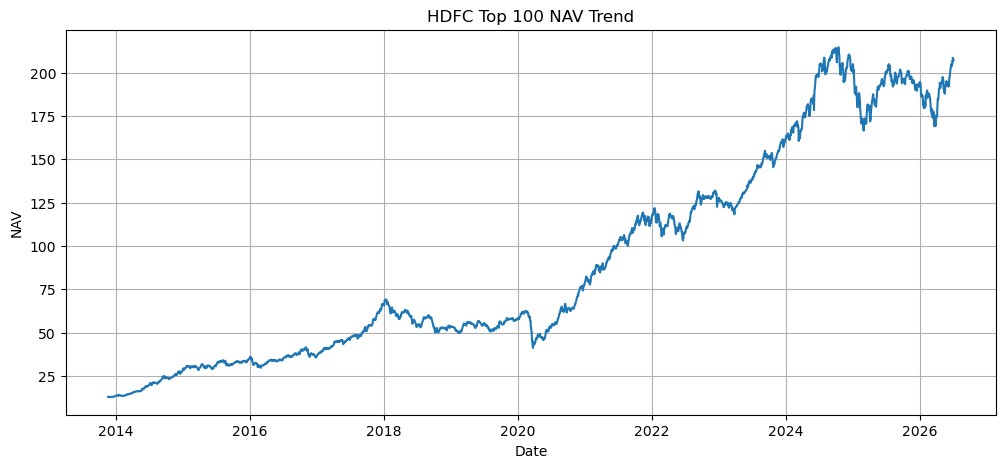

In [27]:
# it shows tpo 100 nav trends

import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/HDFC_Top100.csv")

df["date"] = pd.to_datetime(df["date"], dayfirst=True)

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["nav"])

plt.title("HDFC Top 100 NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)

plt.show()



In [28]:
# Unique Fund Houses

print("Unique Fund Houses")

print(fund_master["fund_house"].unique())

print("Count:",
      fund_master["fund_house"].nunique())


Unique Fund Houses
['SBI Mutual Fund' 'HDFC Mutual Fund' 'ICICI Prudential MF'
 'Nippon India MF' 'Kotak Mahindra MF' 'Axis Mutual Fund'
 'Aditya Birla Sun Life MF' 'UTI Mutual Fund' 'Mirae Asset MF'
 'DSP Mutual Fund']
Count: 10


In [29]:
# Categories
print("Categories")

print(fund_master["category"].unique())

Categories
['Equity' 'Debt']


In [30]:
# Sub Categories
print("Sub Categories")

print(fund_master["sub_category"].unique())

Sub Categories
['Large Cap' 'Small Cap' 'Gilt' 'Mid Cap' 'Short Duration' 'Value'
 'Liquid' 'Index/ETF' 'Flexi Cap' 'Index' 'Large & Mid Cap' 'ELSS']


In [31]:
# Risk Categories
print("Risk Categories")

print(fund_master["risk_category"].unique())

Risk Categories
['Moderate' 'Very High' 'Low' 'High' 'Moderately High']


In [32]:
# Risk Distribution
fund_master["risk_category"].value_counts()

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [33]:
# AMFI Validation
master_codes = set(fund_master["amfi_code"])

nav_codes = set(nav_history["amfi_code"])

missing_codes = master_codes - nav_codes

print("Total Fund Master Codes:", len(master_codes))

print("Total NAV Codes:", len(nav_codes))

print("Missing Codes:", len(missing_codes))

Total Fund Master Codes: 40
Total NAV Codes: 40
Missing Codes: 0


In [34]:
print("="*50)
print("DAY 1 DATA QUALITY REPORT")
print("="*50)

print("Fund Master Shape:", fund_master.shape)
print("NAV History Shape:", nav_history.shape)

print("\nMissing Values:")
print(fund_master.isnull().sum().sum())

print("\nDuplicate Rows:")
print(fund_master.duplicated().sum())

print("\nUnique Fund Houses:")
print(fund_master["fund_house"].nunique())

print("\nUnique Categories:")
print(fund_master["category"].nunique())

print("\nAMFI Validation:")
print("Missing Codes:", len(missing_codes))



DAY 1 DATA QUALITY REPORT
Fund Master Shape: (40, 15)
NAV History Shape: (46000, 3)

Missing Values:
0

Duplicate Rows:
0

Unique Fund Houses:
10

Unique Categories:
2

AMFI Validation:
Missing Codes: 0
